## Real data: D–T2 fit on sub-M1 (ex vivo macaque), slice 42

Fits the constrained model to 30 white-matter voxels, using the real acquisition (6 TEs, 28-78 ms).

In [18]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae



#### Check: is averaging over gradient directions correct?
Simulate one fibre (stick), compute its signal for every gradient direction, then average per b-value as in the preprocessing.

**Result:** the averaging is correct. But the averaged fibre signal decays more slowly than exp(-b·MD) at high b. Our model assumes simple exponentials, so this likely puts extra mass at low D.

In [19]:
DATA = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
b_per_volume = np.loadtxt(f"{DATA}/sub-M1_acq-MultiDim_run-2_dwi.bval") / 1000.0   # b of each volume (ms/µm²)
g_per_volume = np.loadtxt(f"{DATA}/sub-M1_acq-MultiDim_run-2_dwi.bvec")            # gradient direction of each volume

# fake fibre: water moves only along x
D_par = 1.5                        # diffusivity along the fibre
MD = D_par / 3                     # its mean diffusivity
fibre = np.array([1.0, 0.0, 0.0])

# signal each volume would measure from this fibre
alignment = g_per_volume @ fibre   # 1 = gradient along the fibre, 0 = across it
signal_per_volume = np.exp(-b_per_volume * D_par * alignment ** 2)

print("  b    averaged   exp(-b*MD)")
for b in [0, 1, 2.5, 5, 7.5, 11.1, 18.1, 25]:
    in_this_shell = np.abs(b_per_volume - b) <= 0.05          # True for volumes with this b
    averaged = signal_per_volume[in_this_shell].mean()        # average them, like the preprocessing
    print(f"{b:5.1f}   {averaged:.3f}      {np.exp(-b * MD):.3f}")

  b    averaged   exp(-b*MD)
  0.0   1.000      1.000
  1.0   0.658      0.607
  2.5   0.421      0.287
  5.0   0.240      0.082
  7.5   0.153      0.024
 11.1   0.194      0.004
 18.1   0.141      0.000
 25.0   0.116      0.000


#### Build Y for one slice
Average the volumes for each b-value within each run (one run per TE), in white-matter voxels only.
Uses b ≤ 11100 s/mm² for now. At long TE the higher shells are close to the background level.

Slice 42: 3679 WM voxels
Background region: 1254 voxels

-- Run 1  (TE = 28.120 ms) --
  background: mean 5008, mean/std 5.05
  b=     0  ->  averaged  7 volumes,  noise floor    6178,  clipped  0.0%
  b=  1000  ->  averaged 12 volumes,  noise floor    5621,  clipped  0.0%
  b=  2500  ->  averaged 12 volumes,  noise floor    5262,  clipped  0.0%
  b=  5000  ->  averaged 12 volumes,  noise floor    5109,  clipped  0.0%
  b=  7500  ->  averaged 12 volumes,  noise floor    5024,  clipped  0.0%
  b= 11100  ->  averaged 32 volumes,  noise floor    4975,  clipped  0.0%

-- Run 2  (TE = 33.000 ms) --
  background: mean 4938, mean/std 5.93
  b=     0  ->  averaged  8 volumes,  noise floor    5668,  clipped  0.0%
  b=  1000  ->  averaged 12 volumes,  noise floor    5348,  clipped  0.0%
  b=  2500  ->  averaged 12 volumes,  noise floor    5164,  clipped  0.0%
  b=  5000  ->  averaged 12 volumes,  noise floor    5050,  clipped  0.0%
  b=  7500  ->  averaged 12 volumes,  noise floor    4997,  clip

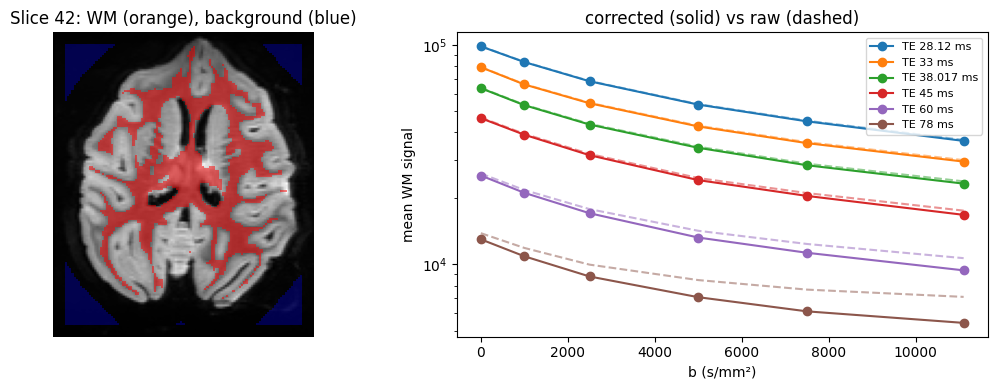

In [38]:
"""
Build the D-T2 signal matrix Y for ONE axial slice of sub-M1, using WM_mask_dwispace.nii.gz.

- Reads only the chosen slice from each run (low memory, fast)
- Removes the noise floor PER VOLUME, before averaging:
      A = sqrt(max(M^2 - mean(background^2), 0))
  For a multi-channel magnitude image E[M^2] = A^2 + 2N*sigma^2, and the mean of the
  squared background (no signal) estimates 2N*sigma^2 directly, so N does not need to be known.
- Averages volumes sharing the same b-value within each run (powder average)
- Y shape: (nTE * nB, V), rows ordered TE-major then b; acq_table gives (b, TE) per row
"""

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

# ---------------------------------------------
# 0. CONFIGURATION
# ---------------------------------------------
DATA_DIR   = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
OUT_DIR    = os.path.join(DATA_DIR, "preprocessed")
MASK_PATH  = os.path.join(OUT_DIR, "WM_mask_dwispace.nii.gz")
BRAIN_PATH = os.path.join(DATA_DIR, "bet4animal_brainmask_f08_mask.nii.gz")
os.makedirs(OUT_DIR, exist_ok=True)

SLICE_IDX = 42    # axial (3rd axis) slice; 42 has the most WM voxels (3679)

TE_BY_RUN = {1: 28.12, 2: 33.0, 3: 38.017, 4: 45.0, 5: 60.0, 6: 78.0}
RUNS      = [1, 2, 3, 4, 5, 6]   # [2, 4, 5, 6] = single diffusion time only
COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0])
#COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0])
BVAL_TOL  = 50.0

NOISE_CORRECT = True   # False reproduces the old, uncorrected Y
BG_DILATE     = 10     # background = this many voxels away from the brain mask
BG_EDGE       = 5      # and this many voxels away from the image border

TE_vals = np.array([TE_BY_RUN[r] for r in RUNS])


# ---------------------------------------------
# 1. MASKS FOR THE SLICE
# ---------------------------------------------
mask_img   = nib.load(MASK_PATH)
mask_slice = mask_img.get_fdata()[:, :, SLICE_IDX] > 0
n_voxels   = int(mask_slice.sum())
print(f"Slice {SLICE_IDX}: {n_voxels} WM voxels")

brain_img = nib.load(BRAIN_PATH)
if brain_img.shape[:3] != mask_img.shape:
    raise ValueError(f"Brain mask grid {brain_img.shape[:3]} does not match WM mask {mask_img.shape}")
brain_slice = brain_img.get_fdata()[:, :, SLICE_IDX] > 0
bg_slice = ~binary_dilation(brain_slice, iterations=BG_DILATE)
bg_slice[:BG_EDGE] = bg_slice[-BG_EDGE:] = False
bg_slice[:, :BG_EDGE] = bg_slice[:, -BG_EDGE:] = False
print(f"Background region: {int(bg_slice.sum())} voxels")


# ---------------------------------------------
# 2. PER-RUN NOISE CORRECTION + SHELL AVERAGES ON THE SLICE
# ---------------------------------------------
def load_slice(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.nii.gz")
    img  = nib.load(path)
    if img.shape[:3] != mask_img.shape or not np.allclose(img.affine, mask_img.affine, atol=1e-3):
        raise ValueError(f"Run {run_idx} grid {img.shape[:3]} does not match mask {mask_img.shape}")
    return np.asarray(img.dataobj[:, :, SLICE_IDX, :], dtype=np.float32)   # (x, y, nvol)


def load_bvals(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.bval")
    return np.loadtxt(path).ravel()


rows, rows_raw, floor_rows, clipped_rows = [], [], [], []
for run_idx in RUNS:
    print(f"\n-- Run {run_idx}  (TE = {TE_BY_RUN[run_idx]:.3f} ms) --")
    vol   = load_slice(run_idx)                                  # (x, y, nvol)
    raw   = vol[mask_slice].astype(np.float64)                   # (V, nvol)
    bg    = vol[bg_slice].astype(np.float64)                     # (n_bg, nvol)
    bvals = load_bvals(run_idx)

    noise_sq = (bg ** 2).mean(axis=0)                            # (nvol,) = 2N*sigma^2 per volume
    print(f"  background: mean {bg.mean():.0f}, mean/std {bg.mean() / bg.std():.2f}")

    if NOISE_CORRECT:
        diff = raw ** 2 - noise_sq[None, :]
        clipped = diff < 0                                       # voxel/volume below the noise floor
        data = np.sqrt(np.maximum(diff, 0))
    else:
        clipped = np.zeros_like(raw, dtype=bool)
        data = raw

    for bval in COMMON_BVALS:
        sel = np.abs(bvals - bval) <= BVAL_TOL
        if not sel.any():
            raise ValueError(f"No volumes for b={bval:.0f} in run {run_idx}")
        rows.append(data[:, sel].mean(axis=1))
        rows_raw.append(raw[:, sel].mean(axis=1))
        floor_rows.append(np.sqrt(noise_sq[sel].mean()))
        clipped_rows.append(clipped[:, sel].mean())
        print(f"  b={bval:>6.0f}  ->  averaged {sel.sum():2d} volumes,"
              f"  noise floor {floor_rows[-1]:7.0f},  clipped {100 * clipped_rows[-1]:4.1f}%")


# ---------------------------------------------
# 3. BUILD Y AND SAVE
# ---------------------------------------------
nB, nTE = len(COMMON_BVALS), len(RUNS)
Y     = np.stack(rows)                                                    # (nTE*nB, V)
Y_raw = np.stack(rows_raw)
acq = np.column_stack([np.tile(COMMON_BVALS, nTE), np.repeat(TE_vals, nB)])  # (b, TE)
voxel_xy = np.argwhere(mask_slice)                                        # to map columns back

tag = f"slice{SLICE_IDX}"
suffix = "_nc" if NOISE_CORRECT else ""
np.save(os.path.join(OUT_DIR, f"Y_{tag}{suffix}.npy"),          Y)
np.save(os.path.join(OUT_DIR, f"noise_floor_{tag}.npy"),        np.array(floor_rows))   # sqrt(2N*sigma^2) per row
np.save(os.path.join(OUT_DIR, f"acq_table_{tag}.npy"),          acq)
np.save(os.path.join(OUT_DIR, f"voxel_xy_{tag}.npy"),           voxel_xy)
np.save(os.path.join(OUT_DIR, "TE_vals.npy"),                   TE_vals)
np.save(os.path.join(OUT_DIR, "bvals_common.npy"),              COMMON_BVALS)
print(f"\nSaved Y_{tag}{suffix}.npy, shape {Y.shape}  ({nTE} TEs x {nB} b-values, {n_voxels} voxels)")


# ---------------------------------------------
# 4. SANITY CHECKS
# ---------------------------------------------
print(f"Any NaN: {np.isnan(Y).any()}   Any Inf: {np.isinf(Y).any()}")
print(f"Worst row: {100 * max(clipped_rows):.1f}% of voxel-volumes clipped at 0 "
      "(more than a few % means the correction is unreliable for that row)")

for label, M in [("raw", Y_raw), ("corrected", Y)]:
    s0 = M[0::nB].mean(axis=1)
    T2_mono = -1 / np.polyfit(TE_vals, np.log(s0), 1)[0]
    print(f"{label:>9}: mean WM b=0 per TE {[round(float(s)) for s in s0]},  mono-exp T2 ~ {T2_mono:.1f} ms")
    if np.any(np.diff(s0) > 0):
        print(f"! {label}: b=0 signal increases with TE somewhere: check scaling between runs")

b0_slice = load_slice(RUNS[0])[..., np.abs(load_bvals(RUNS[0])) <= BVAL_TOL].mean(-1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(b0_slice.T, cmap="gray", origin="lower")
ax[0].imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.5, origin="lower")
ax[0].imshow(np.ma.masked_where(~bg_slice.T, bg_slice.T), cmap="winter", alpha=0.3, origin="lower")
ax[0].set_title(f"Slice {SLICE_IDX}: WM (orange), background (blue)"); ax[0].axis("off")
for i, te in enumerate(TE_vals):
    line, = ax[1].semilogy(COMMON_BVALS, Y[i * nB:(i + 1) * nB].mean(1), "o-", label=f"TE {te:g} ms")
    ax[1].semilogy(COMMON_BVALS, Y_raw[i * nB:(i + 1) * nB].mean(1), "--", color=line.get_color(), alpha=0.5)
ax[1].set_xlabel("b (s/mm²)"); ax[1].set_ylabel("mean WM signal")
ax[1].set_title("corrected (solid) vs raw (dashed)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Slice 42: 3679 WM voxels

-- Run 1  (TE = 28.120 ms) --
  b=     0  ->  averaged 7 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32 volumes

-- Run 2  (TE = 33.000 ms) --
  b=     0  ->  averaged 8 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32 volumes

-- Run 3  (TE = 38.017 ms) --
  b=     0  ->  averaged 9 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32 volumes

-- Run 4  (TE = 45.000 ms) --
  b=     0  ->  averaged 8 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32

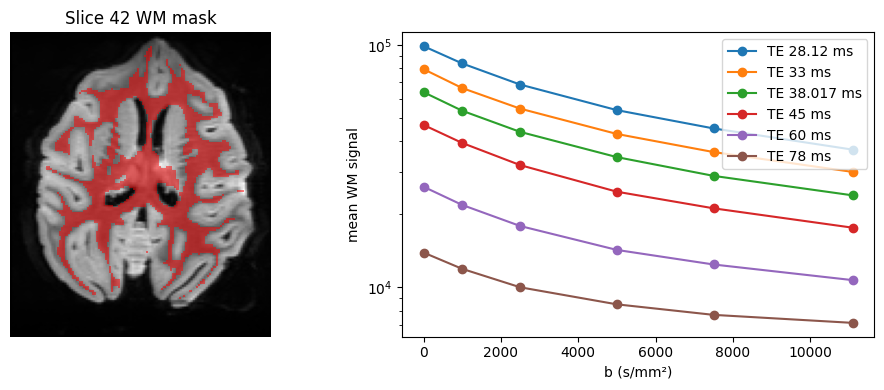

In [32]:
"""
Build the D-T2 signal matrix Y for ONE axial slice of sub-M1, using WM_mask_dwispace.nii.gz.

- Reads only the chosen slice from each run (low memory, fast)
- Averages volumes sharing the same b-value within each run (powder average)
- Y shape: (nTE * nB, V), rows ordered TE-major then b; acq_table gives (b, TE) per row
"""

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# ---------------------------------------------
# 0. CONFIGURATION
# ---------------------------------------------
DATA_DIR  = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
OUT_DIR   = os.path.join(DATA_DIR, "preprocessed")
MASK_PATH = os.path.join(OUT_DIR, "WM_mask_dwispace.nii.gz")
os.makedirs(OUT_DIR, exist_ok=True)

SLICE_IDX = 42    # axial (3rd axis) slice; 42 has the most WM voxels (3679)

TE_BY_RUN = {1: 28.12, 2: 33.0, 3: 38.017, 4: 45.0, 5: 60.0, 6: 78.0}
RUNS      = [1, 2, 3, 4, 5, 6]   # [2, 4, 5, 6] = single diffusion time only
COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0])
#COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0])
BVAL_TOL  = 50.0

TE_vals = np.array([TE_BY_RUN[r] for r in RUNS])


# ---------------------------------------------
# 1. MASK FOR THE SLICE
# ---------------------------------------------
mask_img   = nib.load(MASK_PATH)
mask_slice = mask_img.get_fdata()[:, :, SLICE_IDX] > 0
n_voxels   = int(mask_slice.sum())
print(f"Slice {SLICE_IDX}: {n_voxels} WM voxels")


# ---------------------------------------------
# 2. PER-RUN SHELL AVERAGES ON THE SLICE
# ---------------------------------------------
def load_slice(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.nii.gz")
    img  = nib.load(path)
    if img.shape[:3] != mask_img.shape or not np.allclose(img.affine, mask_img.affine, atol=1e-3):
        raise ValueError(f"Run {run_idx} grid {img.shape[:3]} does not match mask {mask_img.shape}")
    return np.asarray(img.dataobj[:, :, SLICE_IDX, :], dtype=np.float32)   # (x, y, nvol)


def load_bvals(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.bval")
    return np.loadtxt(path).ravel()


rows = []
for run_idx in RUNS:
    print(f"\n-- Run {run_idx}  (TE = {TE_BY_RUN[run_idx]:.3f} ms) --")
    data  = load_slice(run_idx)[mask_slice]          # (V, nvol)
    bvals = load_bvals(run_idx)
    for bval in COMMON_BVALS:
        sel = np.abs(bvals - bval) <= BVAL_TOL
        if not sel.any():
            raise ValueError(f"No volumes for b={bval:.0f} in run {run_idx}")
        rows.append(data[:, sel].mean(axis=1))
        print(f"  b={bval:>6.0f}  ->  averaged {sel.sum()} volumes")


# ---------------------------------------------
# 3. BUILD Y AND SAVE
# ---------------------------------------------
nB, nTE = len(COMMON_BVALS), len(RUNS)
Y   = np.stack(rows)                                                      # (nTE*nB, V)
acq = np.column_stack([np.tile(COMMON_BVALS, nTE), np.repeat(TE_vals, nB)])  # (b, TE)
voxel_xy = np.argwhere(mask_slice)                                        # to map columns back

tag = f"slice{SLICE_IDX}"
np.save(os.path.join(OUT_DIR, f"Y_{tag}.npy"),        Y)
np.save(os.path.join(OUT_DIR, f"acq_table_{tag}.npy"), acq)
np.save(os.path.join(OUT_DIR, f"voxel_xy_{tag}.npy"),  voxel_xy)
np.save(os.path.join(OUT_DIR, "TE_vals.npy"),           TE_vals)
np.save(os.path.join(OUT_DIR, "bvals_common.npy"),      COMMON_BVALS)
print(f"\nY shape: {Y.shape}  ({nTE} TEs x {nB} b-values, {n_voxels} voxels)")


# ---------------------------------------------
# 4. SANITY CHECKS
# ---------------------------------------------
print(f"Any NaN: {np.isnan(Y).any()}   Any Inf: {np.isinf(Y).any()}")
s0 = Y[0::nB].mean(axis=1)
print("Mean WM b=0 per TE:", {float(t): round(float(s), 1) for t, s in zip(TE_vals, s0)})
print(f"Mono-exponential WM T2 ~ {-1 / np.polyfit(TE_vals, np.log(s0), 1)[0]:.1f} ms")
if np.any(np.diff(s0) > 0):
    print("! b=0 signal increases with TE somewhere: check scaling between runs")

b0_slice = load_slice(RUNS[0])[..., np.abs(load_bvals(RUNS[0])) <= BVAL_TOL].mean(-1)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(b0_slice.T, cmap="gray", origin="lower")
ax[0].imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.5, origin="lower")
ax[0].set_title(f"Slice {SLICE_IDX} WM mask"); ax[0].axis("off")
for i, te in enumerate(TE_vals):
    ax[1].semilogy(COMMON_BVALS, Y[i * nB:(i + 1) * nB].mean(1), "o-", label=f"TE {te:g} ms")
ax[1].set_xlabel("b (s/mm²)"); ax[1].set_ylabel("mean WM signal"); ax[1].legend()
plt.tight_layout(); plt.show()

In [40]:
print(sorted(os.listdir(OUT)))

['TE_vals.npy', 'WM_mask_dwispace.nii.gz', 'Y_real.npy', 'Y_slice36.npy', 'Y_slice42.npy', 'Y_slice42_nc.npy', 'acq_table.npy', 'acq_table_slice42.npy', 'b0_mean.nii.gz', 'brain.nii.gz', 'brain_mask.nii.gz', 'brain_mixeltype.nii.gz', 'brain_pve_0.nii.gz', 'brain_pve_1.nii.gz', 'brain_pve_2.nii.gz', 'brain_pveseg.nii.gz', 'brain_seg.nii.gz', 'bvals_common.npy', 'fast_mixeltype.nii.gz', 'fast_pve_0.nii.gz', 'fast_pve_1.nii.gz', 'fast_pve_2.nii.gz', 'fast_pve_2_masked.nii.gz', 'fast_pveseg.nii.gz', 'fast_seg.nii.gz', 'noise_floor_slice42.npy', 'run-1_averaged.nii.gz', 'run-2_averaged.nii.gz', 'run-3_averaged.nii.gz', 'run-4_averaged.nii.gz', 'run-5_averaged.nii.gz', 'run-6_averaged.nii.gz', 'voxel_xy_slice42.npy', 'wm_mask.nii.gz', 'wm_mask.npy', 'wm_mask_slice36.png']


#### Plotting helpers

In [21]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

def show_voxelwise_spectra_est(F_est, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        2, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 5.8),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        image = axes[0, col].imshow(
            F_est[:, voxel].reshape(nD, nT2),
            origin="lower",
            aspect="auto",
            extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
        )
        axes[0, col].set_title(f"Estimated: voxel {voxel}")
        axes[0, col].set_xlabel("T2 (ms)")
        axes[0, col].set_ylabel("D")
        fig.colorbar(image, ax=axes[0, col], shrink=0.75)

        # The second row reports the component weights that form this spectrum.
        components = np.arange(W_est.shape[0])
        axes[1, col].bar(components, W_est[:, voxel], 0.5, color="tab:orange")
        axes[1, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")

    plt.show()

def show_weight_scatter(W_x, W_y, x_label="Ground truth", y_label="Estimated"):
    # one point per voxel per component; r = correlation across voxels for that component
    fig, ax = plt.subplots(figsize=(5, 5))
    for k in range(W_x.shape[0]):
        r = np.corrcoef(W_x[k], W_y[k])[0, 1]
        ax.scatter(W_x[k], W_y[k], s=14, alpha=0.7, label=f"W{k + 1}, r = {r:.2f}")
    r_all = np.corrcoef(W_x.ravel(), W_y.ravel())[0, 1]
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel=f"{x_label} weight", ylabel=f"{y_label} weight",
           title=f"Weights across voxels, all components r = {r_all:.2f}")
    ax.set_aspect("equal"); ax.legend()
    plt.show()



#### Fit 1: σ² updated during the fit (K = 3)
Dirichlet and entropy priors on the weights. σ² starts from the initial fit and is re-estimated each iteration.

In [22]:
print(Y)

[[154392.36   144228.52   158629.08   ... 126758.05   214719.52
  217349.73  ]
 [128771.52   121866.5    133640.1    ... 106155.51   177203.81
  178858.55  ]
 [101366.06    97744.21   106139.73   ...  84690.48   137103.58
  136458.67  ]
 ...
 [ 11850.243   10947.684   12079.956  ...  10392.348   15111.61
   15199.289 ]
 [  9766.5625   9318.353   10205.576  ...   8722.2     11863.731
   11739.622 ]
 [  8060.803    8004.07     8541.725  ...   7415.1      9504.328
    9508.556 ]]


In [43]:
import numpy as np
from scipy.optimize import nnls

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
acq      = np.load(f"{OUT}/acq_table_slice42.npy")
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")
floor    = np.load(f"{OUT}/noise_floor_slice42.npy")
near = np.argsort(np.hypot(voxel_xy[:, 0] - 61, voxel_xy[:, 1] - 66))[:30]
Y_raw = np.load(f"{OUT}/Y_slice42.npy")[:, near]
Y_nc  = np.load(f"{OUT}/Y_slice42_nc.npy")[:, near]
b, TE = acq[:, 0] / 1000.0, acq[:, 1]

# 1) is the corrected file really different? (weakest rows)
print(" b     TE   raw     corrected  noise floor")
for r in np.argsort(Y_raw.mean(1))[:4]:
    print(f"{b[r]:4.1f} {TE[r]:5.0f} {Y_raw[r].mean():8.0f} {Y_nc[r].mean():9.0f} {floor[r]:9.0f}")

# 2) edge mass under different fits
def edge_test(Y, T2max, offset=False, rows=None):
    D, T2 = create_DT2_grid(0.01, 0.75, 20, 10.0, T2max, 20)
    A = np.exp(-np.outer(b, D)) * np.exp(-np.outer(TE, 1.0 / T2))
    if offset:
        A = np.hstack([A, np.ones((len(b), 1))])
    rows = np.ones(len(b), bool) if rows is None else rows
    edge_cols = T2 >= np.unique(T2)[-2]                    # last two T2 columns
    edge, off = [], []
    for v in range(Y.shape[1]):
        f, _ = nnls(A[rows], Y[rows, v])
        edge.append(f[:400][edge_cols].sum() / f.sum())
        off.append(f[-1] / f.sum() if offset else 0)
    edge = np.array(edge)
    return f"{(edge > 0.01).sum():2d}/30 voxels, mean edge {edge.mean():.4f}, offset {np.mean(off):.4f}"

weak = (b > 11) & (TE >= 60)
cases = [("raw Y",                       Y_raw, 100, False, None),
         ("corrected Y",                 Y_nc,  100, False, None),
         ("corrected Y, T2max 150",      Y_nc,  150, False, None),
         ("corrected Y + offset column", Y_nc,  100, True,  None),
         ("corrected Y, weak rows out",  Y_nc,  100, False, ~weak)]
for name, Y_, t2max, off, rows in cases:
    print(f"{name:30s} {edge_test(Y_, t2max, off, rows)}")

 b     TE   raw     corrected  noise floor
11.1    78     7588      6023      4557
 7.5    78     7811      6295      4576
 5.0    78     8533      7165      4572
 2.5    78     9607      8427      4559
raw Y                          28/30 voxels, mean edge 0.0275, offset 0.0000
corrected Y                    23/30 voxels, mean edge 0.0193, offset 0.0000
corrected Y, T2max 150         15/30 voxels, mean edge 0.0129, offset 0.0000
corrected Y + offset column     9/30 voxels, mean edge 0.0073, offset 0.0049
corrected Y, weak rows out     19/30 voxels, mean edge 0.0173, offset 0.0000


b values  [ 0.   1.   2.5  5.   7.5 11.1] 

TE values  [28.12  33.    38.017 45.    60.    78.   ] 

Y shape  (36, 30) 

offset: median 0.674, max 1.142  (signal scale: median b=0 ≈ 30.0)


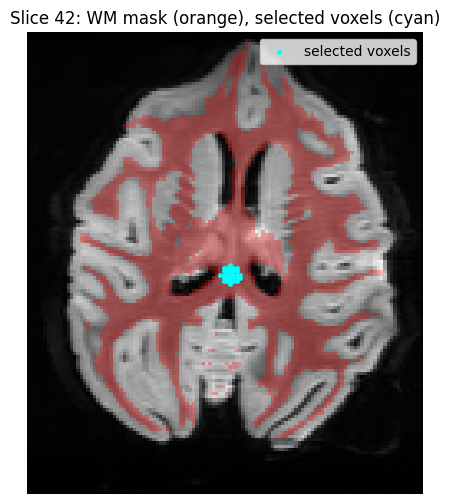

background mean/std: 2.71254


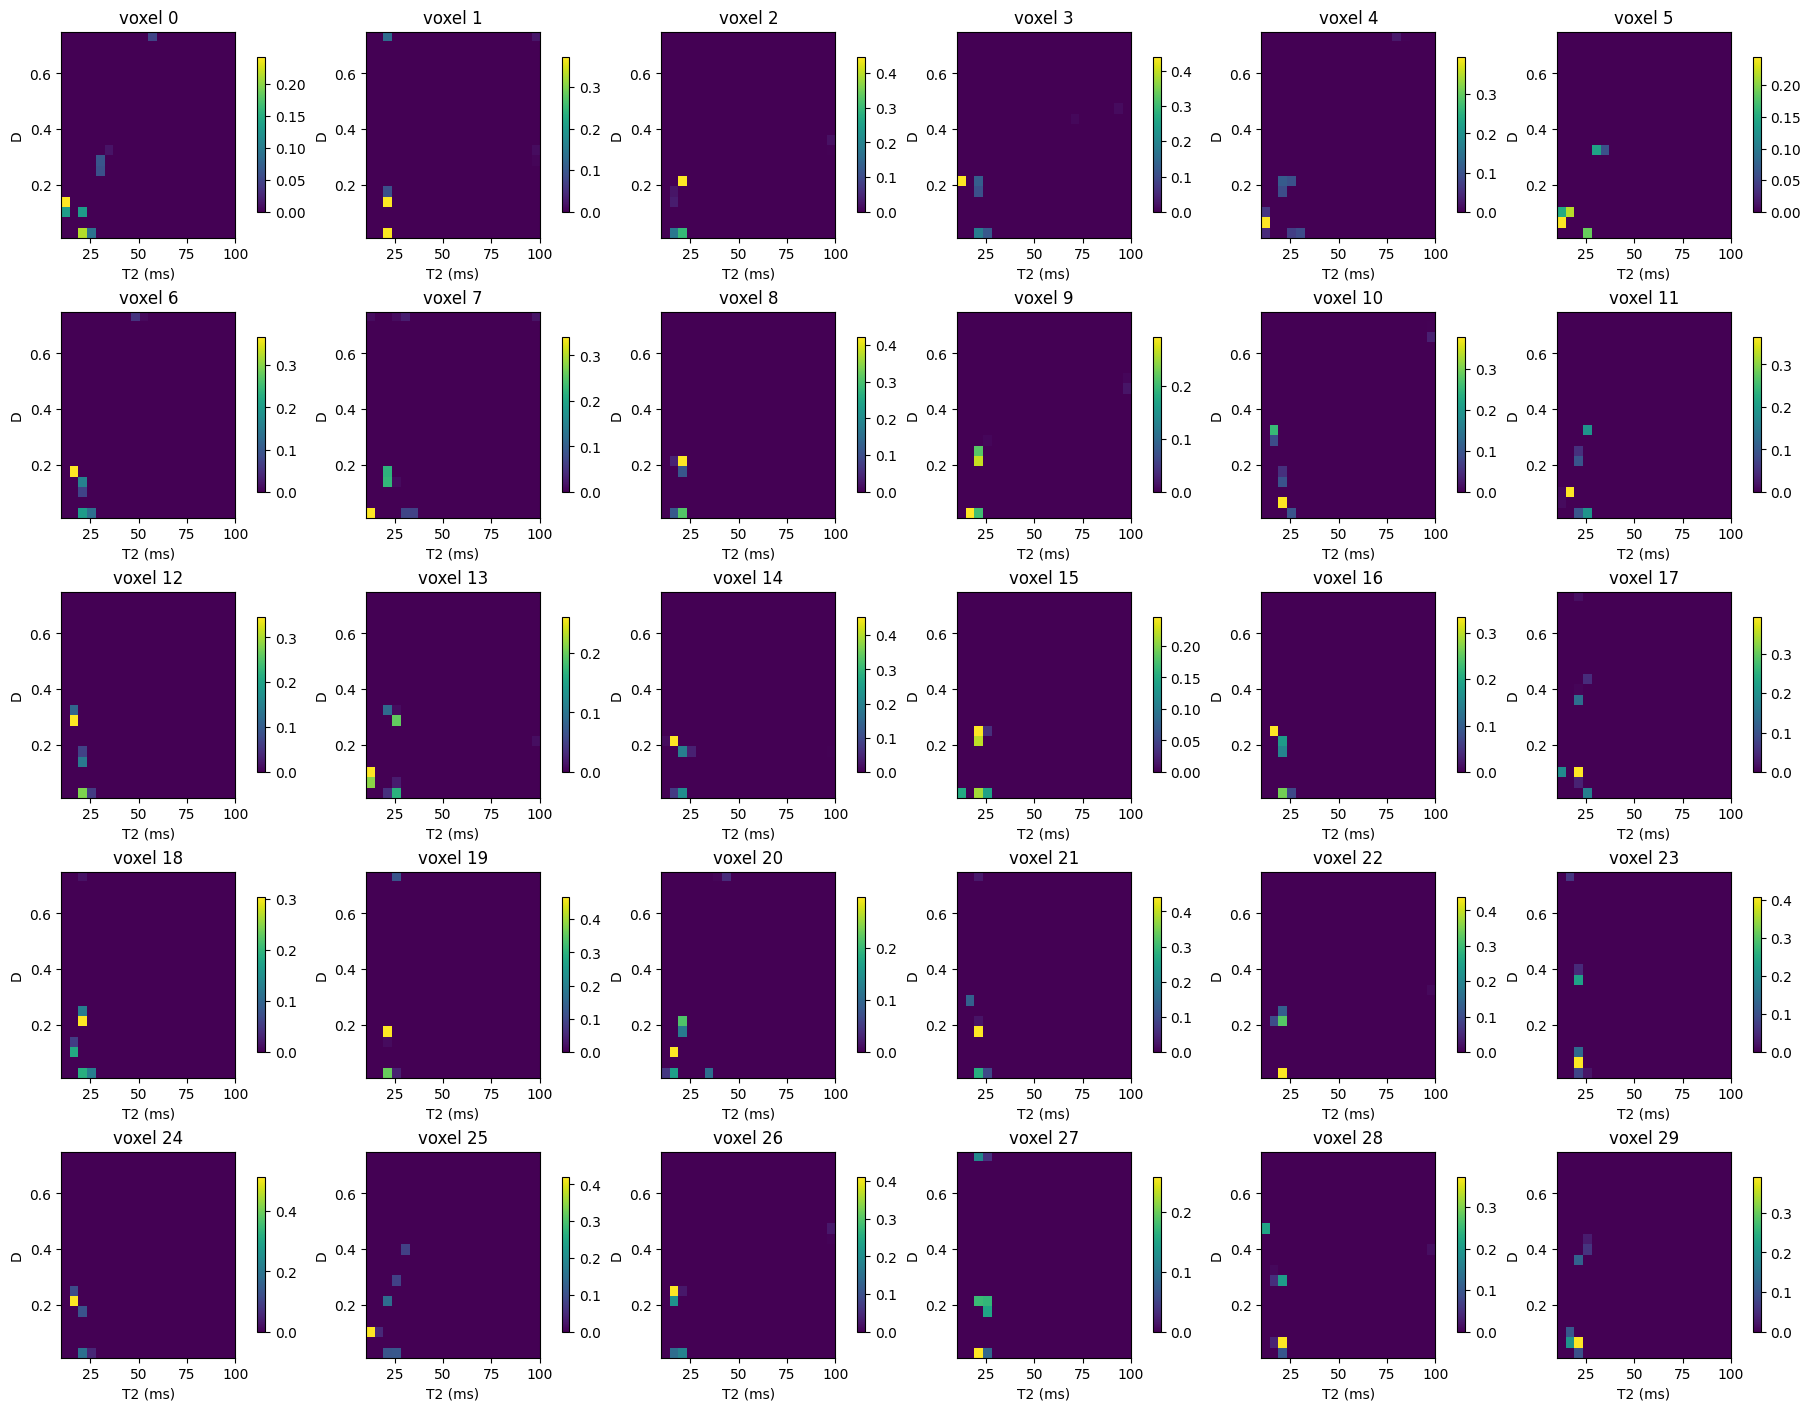

voxel 28: NNLS did not converge at Dmax 0.75, skipped
Dmax 0.75: 29/30 voxels, mass at D>0.5 0.0294, at top D edge 0.0280, its mean D 0.75
Dmax 1.5: 30/30 voxels, mass at D>0.5 0.0144, at top D edge 0.0095, its mean D 1.50
Dmax 2.5: 30/30 voxels, mass at D>0.5 0.0383, at top D edge 0.0057, its mean D 1.04


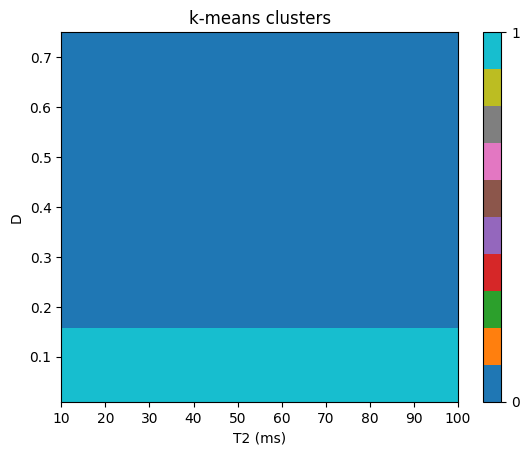

cluster 0: D = 0.255, T2 = 18.6 ms
cluster 1: D = 0.041, T2 = 17.9 ms


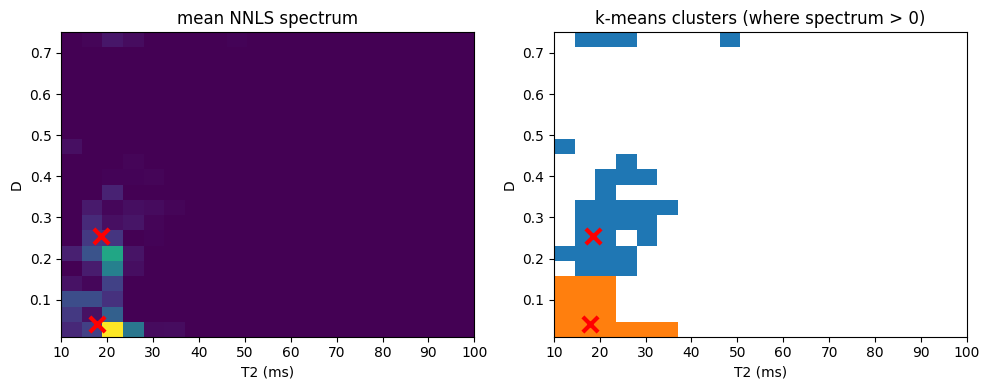

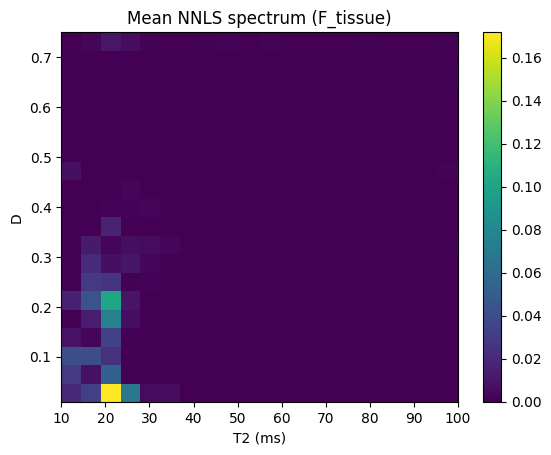

In [54]:
#Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 2, 300.0, 20, 20  
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 0.75, 100.0, 20, 20  
voxels_to_show = [1,3,5,7,9,11,13,15,17,19]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y = np.load(f"{OUT}/Y_slice42_nc.npy")             # (nTE*nB, V)
acq = np.load(f"{OUT}/acq_table_slice42.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")

cx, cy = 61, 66   # ROI centre (x, y) in voxels, read off the map
near = np.argsort(np.hypot(voxel_xy[:, 0] - cx, voxel_xy[:, 1] - cy))[:30]
Y, voxel_xy = Y[:, near], voxel_xy[near] 

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list)
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")
print("Y shape ", Y.shape, "\n")

Y = Y / np.median(Y[0]) * 30   # scale so M0 ≈ 300, like the simulations

# Define fitting parameters
K=2; # Number of compartments
V=Y.shape[1]; # Number of voxels
R=10   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
Y, A = Y[order], A[order]

# per-voxel constant offset (residual noise floor), estimated with NNLS and removed
A_off = np.hstack([A, np.ones((A.shape[0], 1))])
offsets = np.array([nnls(A_off, Y[:, v])[0][-1] for v in range(V)])
print(f"offset: median {np.median(offsets):.3f}, max {offsets.max():.3f}  (signal scale: median b=0 ≈ {np.median(Y[0]):.1f})")
Y = Y - offsets[None, :]

b_list, TE_list = b_list[order], TE_list[order]

U, s, Vmat = apply_SVD_to_A(A, R)

plt.figure(figsize=(6, 6))
plt.imshow(b0_slice.T, cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="selected voxels")
plt.title(f"Slice {SLICE_IDX}: WM mask (orange), selected voxels (cyan)")
plt.legend(loc="upper right"); plt.axis("off"); plt.show()

bg_vals = load_slice(1)[bg_slice][:, np.abs(load_bvals(1)) <= BVAL_TOL].ravel()
print("background mean/std:", bg_vals.mean() / bg_vals.std())

spectra = []
for v in range(V):
    f, _ = nnls(A, Y[:, v])
    spectra.append(f / f.sum() if f.sum() > 0 else f)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
for v, ax in enumerate(axes.ravel()[:V]):
    im = ax.imshow(spectra[v].reshape(nD, nT2), origin="lower", aspect="auto",
                   extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
    ax.set(title=f"voxel {v}", xlabel="T2 (ms)", ylabel="D")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()


from sklearn.cluster import KMeans

tissue_spectrum = np.mean(spectra, axis=0)
tissue_spectrum /= tissue_spectrum.sum()

for Dmax_test in (0.75, 1.5, 2.5):
    D_t, T2_t = create_DT2_grid(0.01, Dmax_test, 20, 10.0, 100.0, 20)
    A_t = np.exp(-np.outer(b_list, D_t)) * np.exp(-np.outer(TE_list, 1.0 / T2_t))
    A_t = np.hstack([A_t, np.ones((A_t.shape[0], 1))])        # offset column
    fast, top_edge, Dc = [], [], []
    for v in range(V):
        try:
            f = nnls(A_t, Y[:, v], maxiter=50 * A_t.shape[1])[0][:-1]
        except RuntimeError:
            print(f"voxel {v}: NNLS did not converge at Dmax {Dmax_test}, skipped")
            continue
        f /= f.sum()
        m = D_t > 0.5
        fast.append(f[m].sum())
        top_edge.append(f[D_t >= np.unique(D_t)[-2]].sum())
        Dc.append((f[m] * D_t[m]).sum() / f[m].sum() if f[m].sum() > 0 else np.nan)
    print(f"Dmax {Dmax_test}: {len(fast)}/{V} voxels, mass at D>0.5 {np.mean(fast):.4f}, "
          f"at top D edge {np.mean(top_edge):.4f}, its mean D {np.nanmedian(Dc):.2f}")


D_mesh, T2_mesh = np.meshgrid(D_vals, T2_vals, indexing='ij')
grid_points = np.column_stack([
    (D_mesh.ravel() - Dmin) / (Dmax - Dmin),
    (T2_mesh.ravel() - T2min) / (T2max - T2min),
])
tissue_spectrum[tissue_spectrum < 0.01 * tissue_spectrum.max()] = 0
tissue_spectrum /= tissue_spectrum.sum()

kmeans = KMeans(n_clusters=K, n_init=10, random_state=0)
kmeans.fit(grid_points, sample_weight=tissue_spectrum)
labels = kmeans.labels_.reshape(nD, nT2)

plt.imshow(labels, origin="lower", aspect="auto", cmap="tab10",
           extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
plt.xlabel("T2 (ms)"); plt.ylabel("D"); plt.title("k-means clusters")
plt.colorbar(ticks=range(K)); plt.show()

F_mean = tissue_spectrum.reshape(nD, nT2)
ext = [T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(F_mean, origin="lower", aspect="auto", extent=ext)
axes[0].set(title="mean NNLS spectrum", xlabel="T2 (ms)", ylabel="D")
axes[1].imshow(np.ma.masked_where(F_mean < 1e-3 * F_mean.max(), labels),
               origin="lower", aspect="auto", extent=ext, cmap="tab10", vmin=0, vmax=9)
axes[1].set(title="k-means clusters (where spectrum > 0)", xlabel="T2 (ms)", ylabel="D")

for i in range(K):
    idxD, idxT2 = np.nonzero(labels == i)
    w = F_mean[idxD, idxT2]
    if w.sum() <= 0:
        continue   # empty cluster: the function falls back to the grid middle
    D_c = np.sum(D_vals[idxD] * w) / w.sum()
    T2_c = np.sum(T2_vals[idxT2] * w) / w.sum()
    print(f"cluster {i}: D = {D_c:.3f}, T2 = {T2_c:.1f} ms")
    for ax in axes:
        ax.scatter(T2_c, D_c, marker="x", s=120, linewidths=3, color="red")
plt.tight_layout(); plt.show()




rng=np.random.default_rng(0)
# Dirichlet vs entropy prior on the same data constrained C (non-negative, simplex on the D–T2 grid)
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

Y_dirichlet = Y

# Set intial conditions
C0_dirichlet, F_tissue =define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)

Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)
# per-voxel NNLS spectra and signal fits: see the NNLS check cell below


# F_tissue is the mean NNLS spectrum over all voxels (one nD x nT2 map), so plot it as one image
plt.imshow(F_tissue, origin="lower", aspect="auto",
           extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
plt.xlabel("T2 (ms)"); plt.ylabel("D"); plt.title("Mean NNLS spectrum (F_tissue)"); plt.colorbar(); plt.show()

# NNLS spectrum f for each voxel, fitted on its own





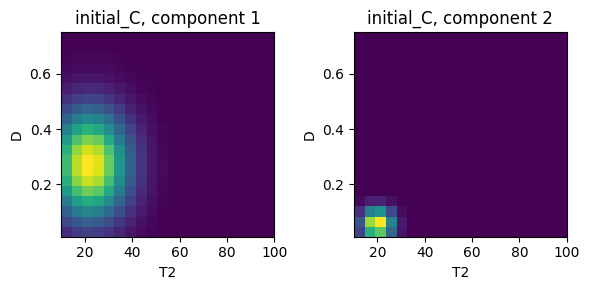



iter 0: loss=670.8615, fit_err=1079.361354, sigma2=0.999409
iter 100: loss=628.9927, fit_err=193.377036, sigma2=0.179053
iter 200: loss=619.0060, fit_err=192.978944, sigma2=0.178684
iter 300: loss=613.6486, fit_err=193.043844, sigma2=0.178744
dirichlet prior: estimated C


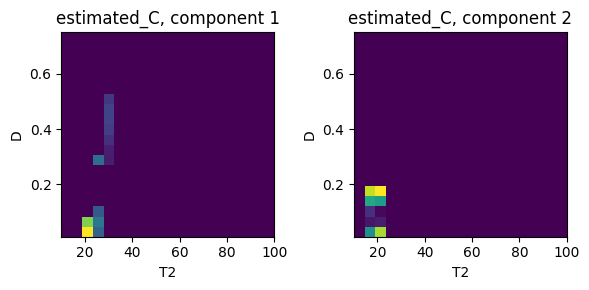

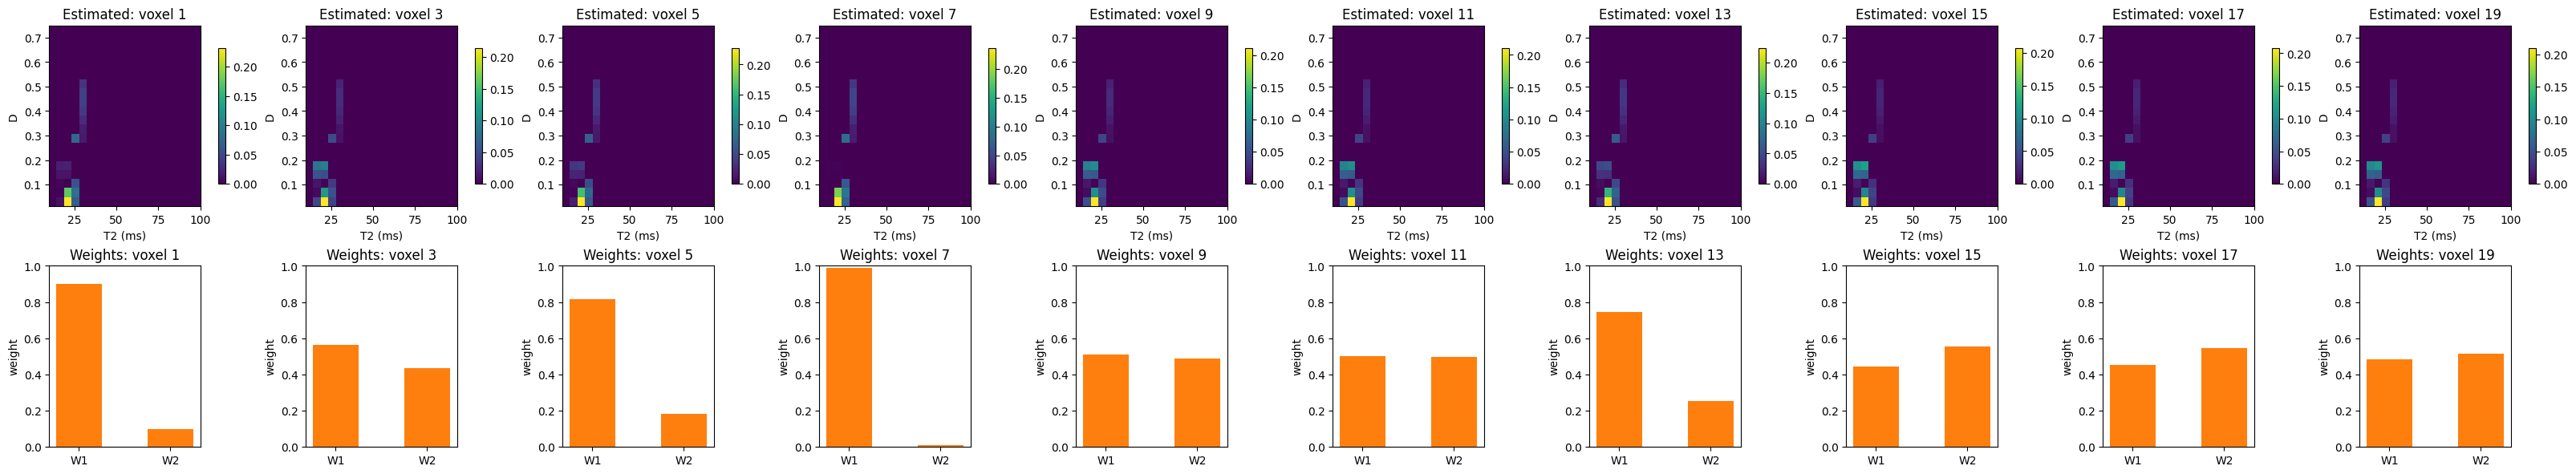

iter 0: loss=843.8921, fit_err=1106.841410, sigma2=1.024853
iter 100: loss=825.4763, fit_err=192.078038, sigma2=0.177850
iter 200: loss=818.6989, fit_err=193.004074, sigma2=0.178707
iter 300: loss=805.7980, fit_err=191.152404, sigma2=0.176993
entropy prior: estimated C


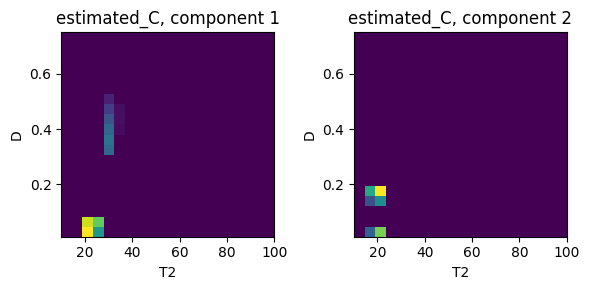

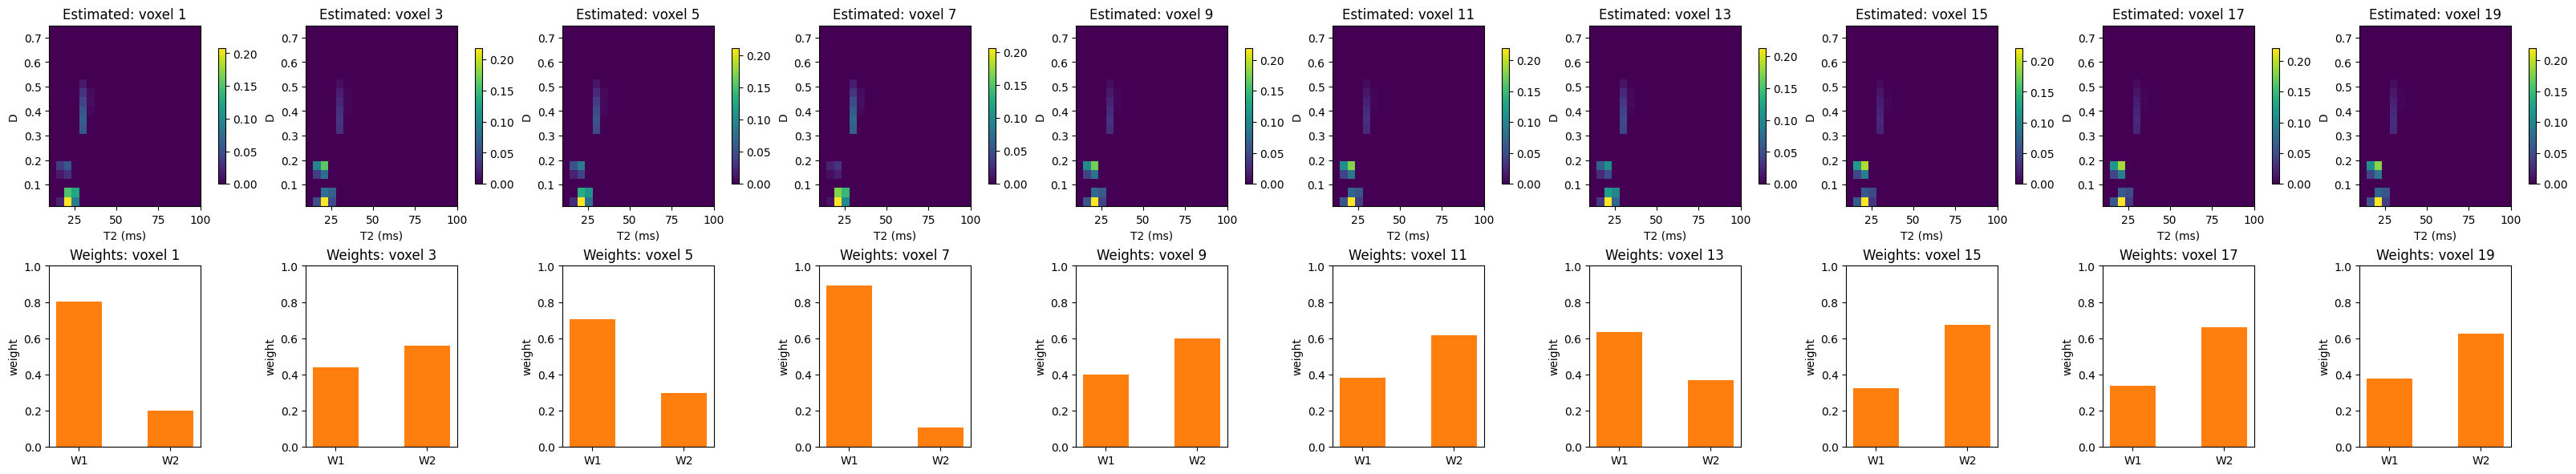

In [55]:

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y_dirichlet - (U @ Csmall0_dirichlet @ W0_dirichlet) * M0_init_dirichlet) ** 2)


show_canonical_spectra([('initial_C', C0_dirichlet)])
print("\n")



for name, kwargs in priors.items():
    # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
    W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
        Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=400,
        sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=True,
        m0_prior=M0_init_dirichlet, m0_prior_sigma=3, alpha_update_start=5,
        c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
        verbose_every=100, **kwargs)
    print(f"{name} prior: estimated C")
    show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
    F_est = C_est_dirichlet @ W_est_dirichlet
    show_voxelwise_spectra_est(F_est, W_est_dirichlet, voxels_to_show)



#### Fit 2: σ² fixed at its starting value (K = 3)
Same as Fit 1, but σ² is not updated.

**Result:** the fixed σ² is too large, so the weight priors take over. Fit error is much worse (Dirichlet ≈ 316, entropy ≈ 561, against ≈ 160 in Fit 1). Updating σ² is better.

b values  [ 0.   1.   2.5  5.   7.5 11.1] 

TE values  [28.12  33.    38.017 45.    60.    78.   ] 

Y shape  (36, 30) 



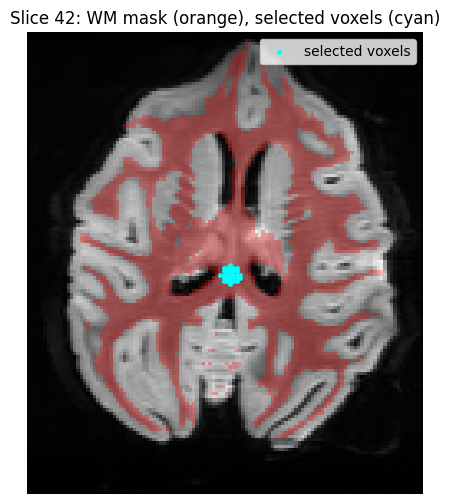

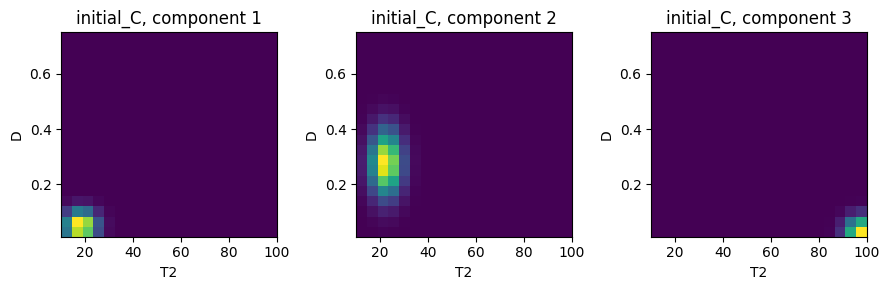



iter 0: loss=275.9813, fit_err=938.941607, sigma2=1.845046


KeyboardInterrupt: 

In [29]:
#Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 1.5, 150.0, 20, 20  
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 0.75, 100.0, 20, 20  
voxels_to_show = [1,3,5,7,9,11,13,15,17,19]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y = np.load(f"{OUT}/Y_slice42.npy")             # (nTE*nB, V)
acq = np.load(f"{OUT}/acq_table_slice42.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")

cx, cy = 61, 66   # ROI centre (x, y) in voxels, read off the map
near = np.argsort(np.hypot(voxel_xy[:, 0] - cx, voxel_xy[:, 1] - cy))[:30]
Y, voxel_xy = Y[:, near], voxel_xy[near] 

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list)
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")
print("Y shape ", Y.shape, "\n")

Y = Y / np.median(Y[0]) * 30   # scale so M0 ≈ 300, like the simulations

# Define fitting parameters
K=3; # Number of compartments
V=Y.shape[1]; # Number of voxels
R=10   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
Y, A = Y[order], A[order]
b_list, TE_list = b_list[order], TE_list[order]
U, s, Vmat = apply_SVD_to_A(A, R)

plt.figure(figsize=(6, 6))
plt.imshow(b0_slice.T, cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="selected voxels")
plt.title(f"Slice {SLICE_IDX}: WM mask (orange), selected voxels (cyan)")
plt.legend(loc="upper right"); plt.axis("off"); plt.show()


rng=np.random.default_rng(0)
# Dirichlet vs entropy prior on the same data constrained C (non-negative, simplex on the D–T2 grid)
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

Y_dirichlet = Y

# Set intial conditions
C0_dirichlet, F_tissue = define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y_dirichlet - (U @ Csmall0_dirichlet @ W0_dirichlet) * M0_init_dirichlet) ** 2)


show_canonical_spectra([('initial_C', C0_dirichlet)])
print("\n")



for name, kwargs in priors.items():
    # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
    W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
        Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=400,
        sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=False,
        m0_prior=M0_init_dirichlet, m0_prior_sigma=3, alpha_update_start=5,
        c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
        verbose_every=100, **kwargs)
    print(f"{name} prior: estimated C")
    show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
    F_est = C_est_dirichlet @ W_est_dirichlet
    show_voxelwise_spectra_est(F_est, W_est_dirichlet, voxels_to_show)



#### Fit 3: Rician noise correction (K = 2)
The background outside the brain sits at about 4500 in every volume. Here it is treated as Rician noise and removed in quadrature: Y = √(Y² − mean background²) for each (b, TE). This removes a lot from weak signals but little from strong ones.

**Result:**
- One tissue component: T2 ≈ 20–30 ms, D < 0.45. Every voxel is ≈ 0.97 on it.
- The second component sits at the long-T2 edge (T2 ≈ 120–150 ms) with about 2% weight

In [ ]:
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 1.5, 150.0, 20, 20  
#Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 0.75, 100.0, 20, 20  
voxels_to_show = [1,3,5,7,9,11,13,15,17,19, 21,23,25,27,29]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y = np.load(f"{OUT}/Y_slice42.npy")             # (nTE*nB, V)
acq = np.load(f"{OUT}/acq_table_slice42.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")

# subtract the signal floor: mean background (well outside the brain) for each (b, TE) row
from scipy.ndimage import binary_dilation
brain_slice = nib.load(os.path.join(DATA_DIR, "bet4animal_brainmask_f08_mask.nii.gz")).get_fdata()[:, :, SLICE_IDX] > 0
bg_slice = ~binary_dilation(brain_slice, iterations=10)
bg_slice[:5] = bg_slice[-5:] = False
bg_slice[:, :5] = bg_slice[:, -5:] = False
floor_sq = np.zeros(len(acq))
for run_idx, te in TE_BY_RUN.items():
    rows_this_run = np.where(acq[:, 1] == te)[0]
    if len(rows_this_run) == 0:
        continue
    bg = load_slice(run_idx)[bg_slice]
    bvals = load_bvals(run_idx)
    for row in rows_this_run:
        floor_sq[row] = (bg[:, np.abs(bvals - acq[row, 0]) <= BVAL_TOL] ** 2).mean()
Y = np.sqrt(np.maximum(Y ** 2 - floor_sq[:, None], 0))   # Rician (quadrature) correction


cx, cy = 61, 66   # ROI centre (x, y) in voxels, read off the map
near = np.argsort(np.hypot(voxel_xy[:, 0] - cx, voxel_xy[:, 1] - cy))[:30]
Y, voxel_xy = Y[:, near], voxel_xy[near] 

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list)
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")
print("Y shape ", Y.shape, "\n")

Y = Y / np.median(Y[0]) * 30   # scale so M0 ≈ 300, like the simulations

# Define fitting parameters
K=2; # Number of compartments
V=Y.shape[1]; # Number of voxels
R=10   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
Y, A = Y[order], A[order]
b_list, TE_list = b_list[order], TE_list[order]
U, s, Vmat = apply_SVD_to_A(A, R)

plt.figure(figsize=(6, 6))
plt.imshow(b0_slice.T, cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="selected voxels")
plt.title(f"Slice {SLICE_IDX}: WM mask (orange), selected voxels (cyan)")
plt.legend(loc="upper right"); plt.axis("off"); plt.show()


rng=np.random.default_rng(0)
# Dirichlet vs entropy prior on the same data constrained C (non-negative, simplex on the D–T2 grid)
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

Y_dirichlet = Y

# Set intial conditions
C0_dirichlet, F_tissue = define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y_dirichlet - (U @ Csmall0_dirichlet @ W0_dirichlet) * M0_init_dirichlet) ** 2)


show_canonical_spectra([('initial_C', C0_dirichlet)])
print("\n")



for name, kwargs in priors.items():
    # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
    W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
        Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=400,
        sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=True,
        m0_prior=M0_init_dirichlet, m0_prior_sigma=3, alpha_update_start=5,
        c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
        verbose_every=100, **kwargs)
    print(f"{name} prior: estimated C")
    show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
    F_est = C_est_dirichlet @ W_est_dirichlet
    show_voxelwise_spectra_est(F_est, W_est_dirichlet, voxels_to_show)


KeyboardInterrupt: 

#### Fit 4: floor subtracted as a constant offset (K = 2)
Same as Fit 3 (same grid, K, priors and σ² handling), but the background is subtracted directly: Y = Y − mean background, for each (b, TE). This removes the same amount from every value.

**Result:**
- No floor component. Both components are tissue: T2 ≈ 20 ms with D < 0.3, and T2 ≈ 35 ms with D ≈ 0.1 and ≈ 0.5.

b values  [ 0.   1.   2.5  5.   7.5 11.1] 

TE values  [28.12  33.    38.017 45.    60.    78.   ] 

Y shape  (36, 30) 



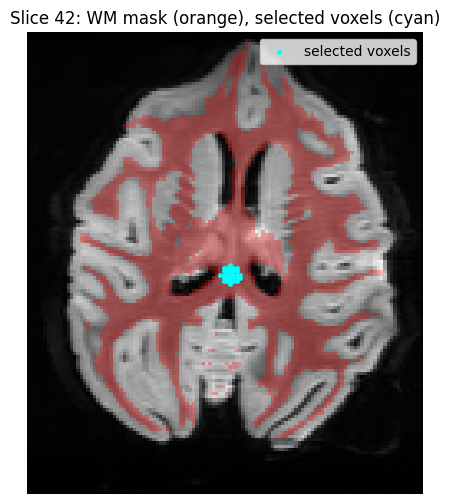

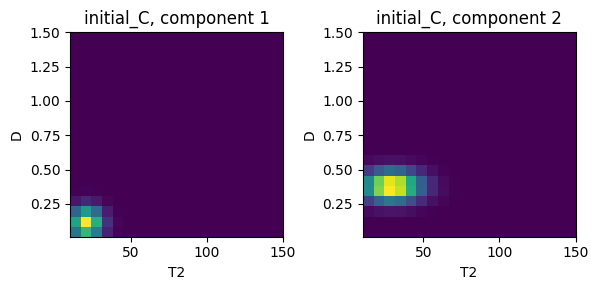



iter 0: loss=670.8424, fit_err=763.244924, sigma2=0.706708
iter 100: loss=928.8674, fit_err=189.848112, sigma2=0.175785
iter 200: loss=890.3233, fit_err=191.804963, sigma2=0.177597
iter 300: loss=889.0675, fit_err=192.232768, sigma2=0.177993
dirichlet prior: estimated C


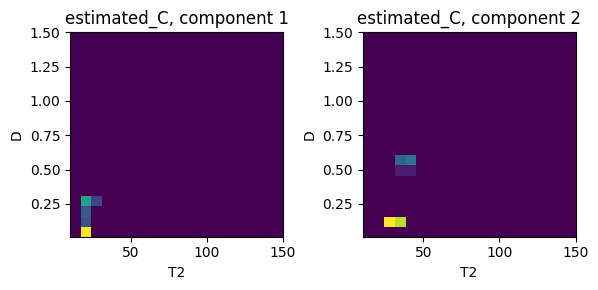

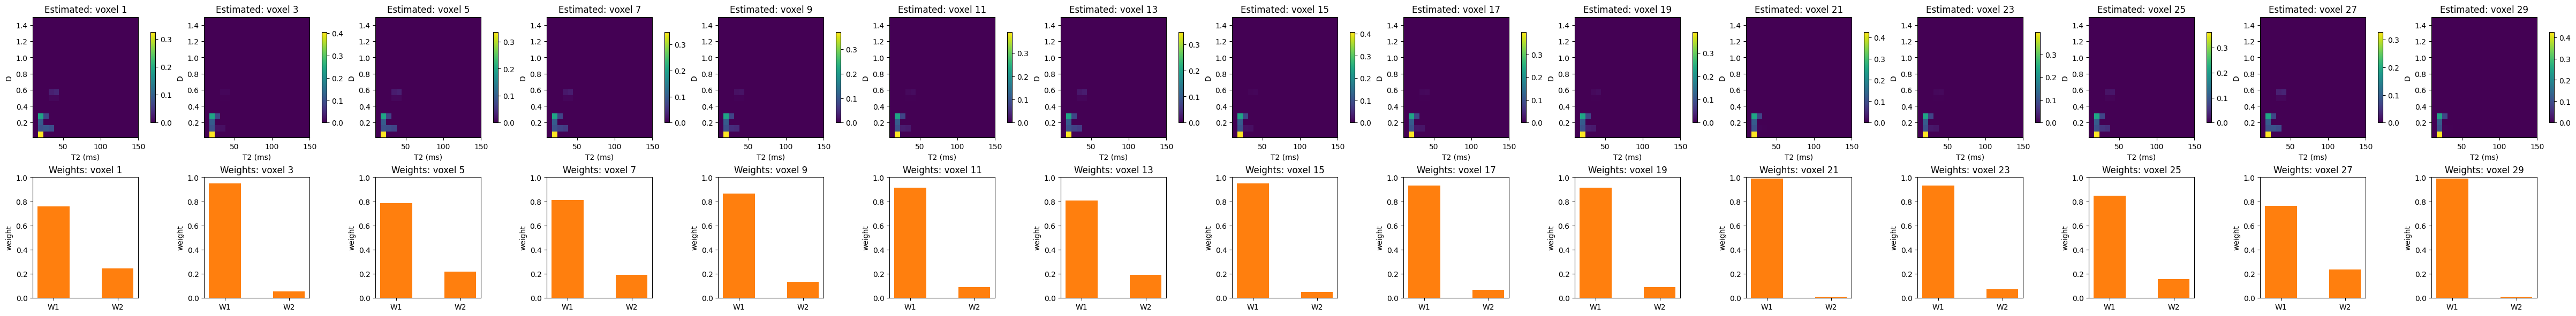

iter 0: loss=727.2946, fit_err=938.104945, sigma2=0.868616
iter 100: loss=1001.6438, fit_err=185.344073, sigma2=0.171615
iter 200: loss=1000.9647, fit_err=185.505860, sigma2=0.171765
iter 300: loss=1000.8121, fit_err=185.557589, sigma2=0.171813
entropy prior: estimated C


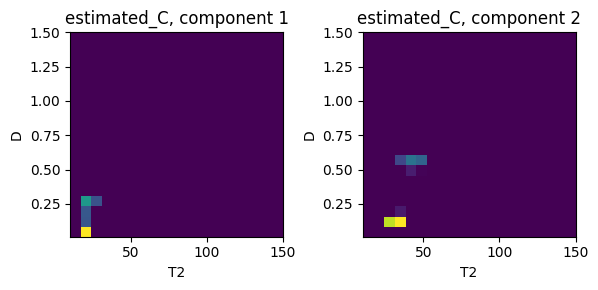

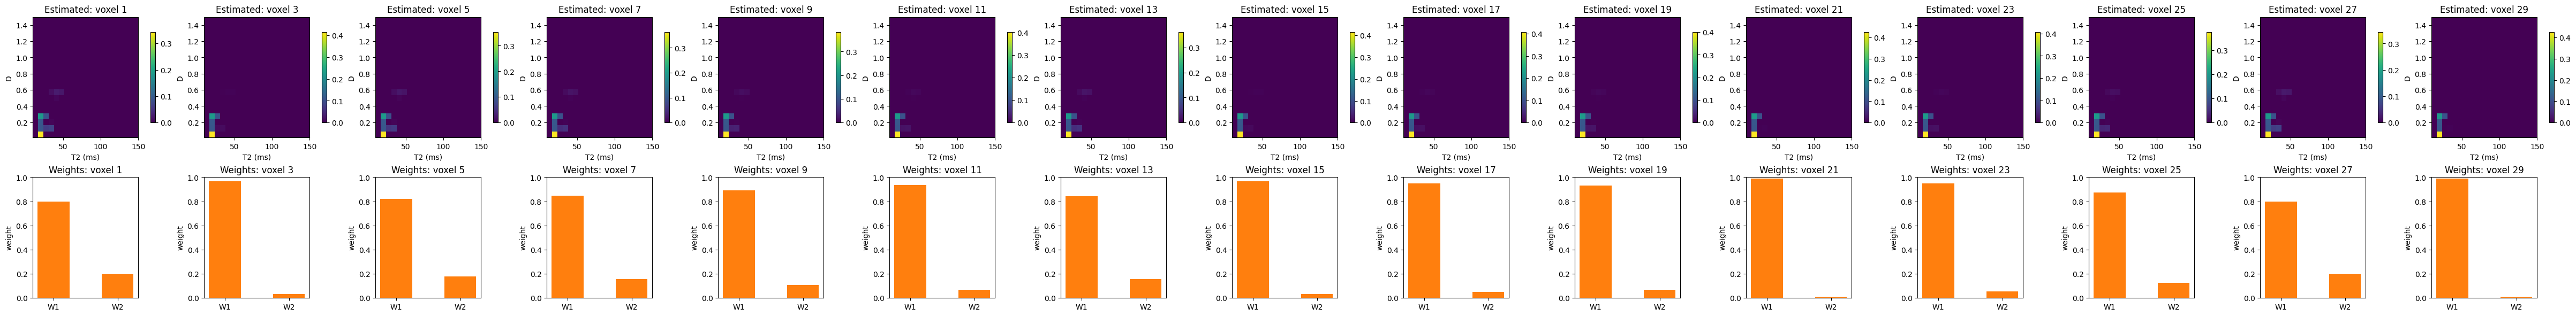

In [ ]:
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 1.5, 150.0, 20, 20  
#Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 0.75, 100.0, 20, 20  
voxels_to_show = [1,3,5,7,9,11,13,15,17,19, 21,23,25,27,29]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y = np.load(f"{OUT}/Y_slice42.npy")             # (nTE*nB, V)
acq = np.load(f"{OUT}/acq_table_slice42.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")

# subtract the signal floor: mean background (well outside the brain) for each (b, TE) row
from scipy.ndimage import binary_dilation
brain_slice = nib.load(os.path.join(DATA_DIR, "bet4animal_brainmask_f08_mask.nii.gz")).get_fdata()[:, :, SLICE_IDX] > 0
bg_slice = ~binary_dilation(brain_slice, iterations=10)
bg_slice[:5] = bg_slice[-5:] = False
bg_slice[:, :5] = bg_slice[:, -5:] = False

floor_sq = np.zeros(len(acq))
for run_idx, te in TE_BY_RUN.items():
    rows_this_run = np.where(acq[:, 1] == te)[0]
    if len(rows_this_run) == 0:
        continue
    bg = load_slice(run_idx)[bg_slice]
    bvals = load_bvals(run_idx)
    for row in rows_this_run:
        floor_sq[row] = bg[:, np.abs(bvals - acq[row, 0]) <= BVAL_TOL].mean()
Y = Y - floor_sq[:, None]   # constant offset subtraction


cx, cy = 61, 66   # ROI centre (x, y) in voxels, read off the map
near = np.argsort(np.hypot(voxel_xy[:, 0] - cx, voxel_xy[:, 1] - cy))[:30]
Y, voxel_xy = Y[:, near], voxel_xy[near] 

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list)
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")
print("Y shape ", Y.shape, "\n")

Y = Y / np.median(Y[0]) * 30   # scale so M0 ≈ 300, like the simulations

# Define fitting parameters
K=2; # Number of compartments
V=Y.shape[1]; # Number of voxels
R=10   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
Y, A = Y[order], A[order]
b_list, TE_list = b_list[order], TE_list[order]
U, s, Vmat = apply_SVD_to_A(A, R)

plt.figure(figsize=(6, 6))
plt.imshow(b0_slice.T, cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="selected voxels")
plt.title(f"Slice {SLICE_IDX}: WM mask (orange), selected voxels (cyan)")
plt.legend(loc="upper right"); plt.axis("off"); plt.show()


rng=np.random.default_rng(0)
# Dirichlet vs entropy prior on the same data constrained C (non-negative, simplex on the D–T2 grid)
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

Y_dirichlet = Y

# Set intial conditions
C0_dirichlet, F_tissue = define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y_dirichlet - (U @ Csmall0_dirichlet @ W0_dirichlet) * M0_init_dirichlet) ** 2)


show_canonical_spectra([('initial_C', C0_dirichlet)])
print("\n")



for name, kwargs in priors.items():
    # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
    W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
        Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=400,
        sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=True,
        m0_prior=M0_init_dirichlet, m0_prior_sigma=3, alpha_update_start=5,
        c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
        verbose_every=100, **kwargs)
    print(f"{name} prior: estimated C")
    show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
    F_est = C_est_dirichlet @ W_est_dirichlet
    show_voxelwise_spectra_est(F_est, W_est_dirichlet, voxels_to_show)


### Summary
- Averaging over directions is correct, but averaged fibres are not simple exponentials at high b.
- Updating σ² during the fit works much better than fixing it.
- The background floor (≈ 4500) behaves like a constant offset, not Rician noise:
  - With the same settings (K = 2), the Rician correction leaves a floor component that uses up one of the two components. Offset subtraction leaves none, so both components describe tissue.

- After offset subtraction, two tissue components remain: T2 ≈ 20 ms at low D, and T2 ≈ 35 ms at higher D.


What if I choose random voxels across the white matter?

b values  [ 0.   1.   2.5  5.   7.5 11.1] 

TE values  [28.12  33.    38.017 45.    60.    78.   ] 

Y shape  (36, 30) 



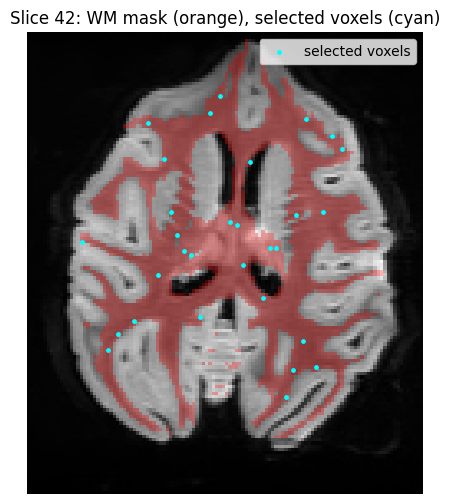

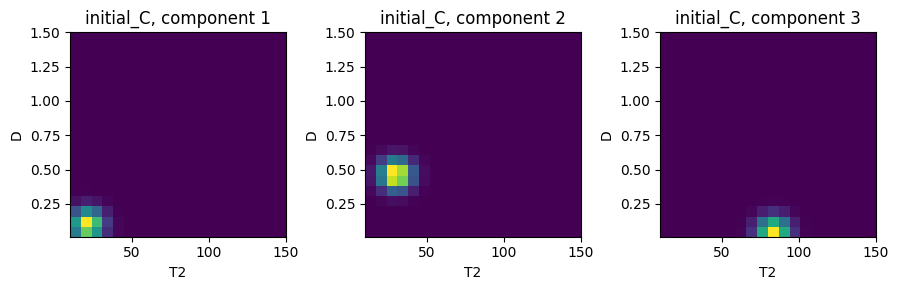



iter 0: loss=578.1472, fit_err=474.921183, sigma2=0.439742
iter 100: loss=697.6157, fit_err=168.500541, sigma2=0.156019
iter 200: loss=692.5613, fit_err=169.980849, sigma2=0.157390
iter 300: loss=692.3566, fit_err=170.045000, sigma2=0.157449
dirichlet prior: estimated C


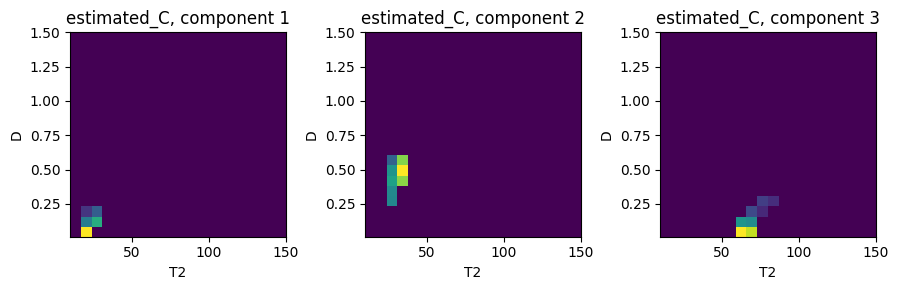

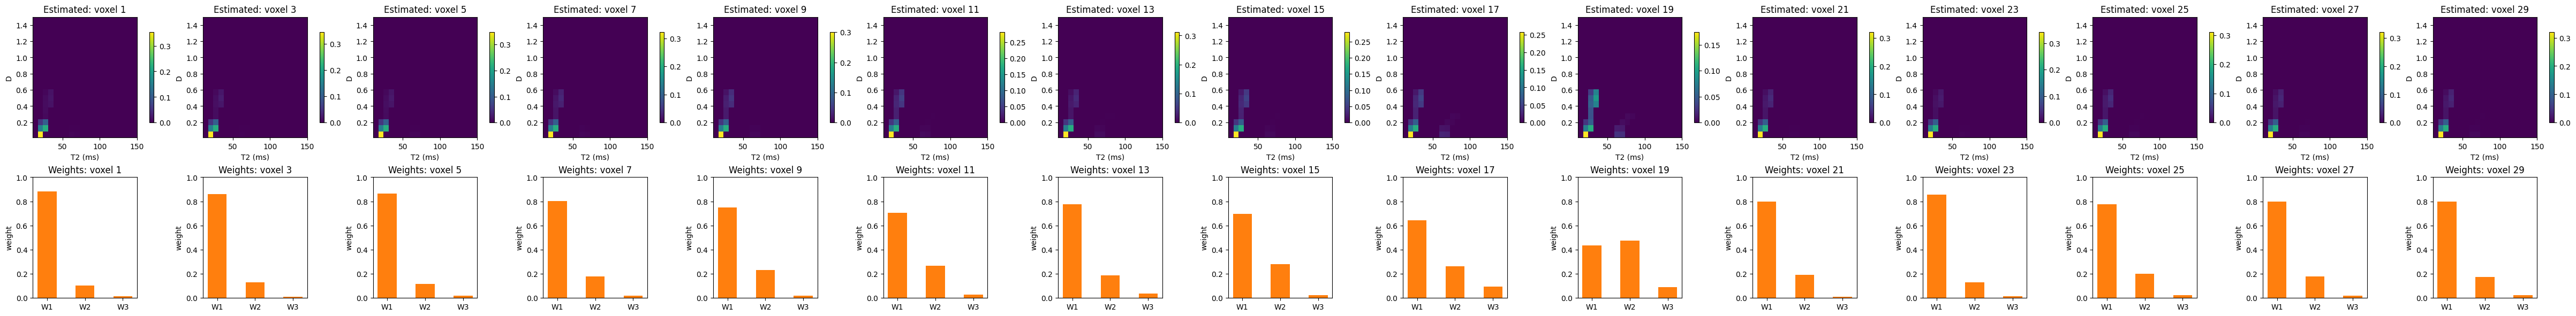

iter 0: loss=770.4838, fit_err=476.641997, sigma2=0.441335
iter 100: loss=804.1954, fit_err=159.500653, sigma2=0.147686
iter 200: loss=789.0998, fit_err=163.185168, sigma2=0.151097
iter 300: loss=788.4097, fit_err=163.392089, sigma2=0.151289
entropy prior: estimated C


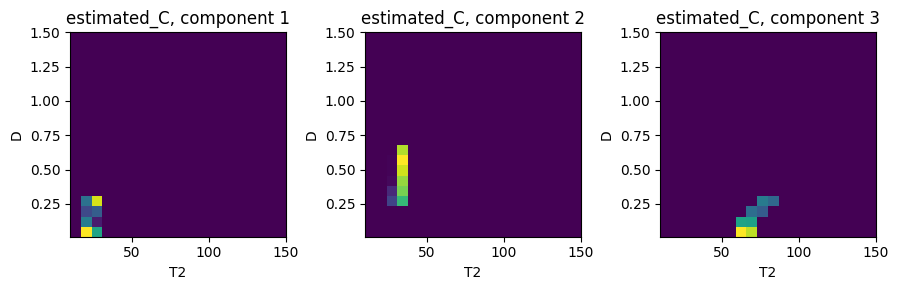

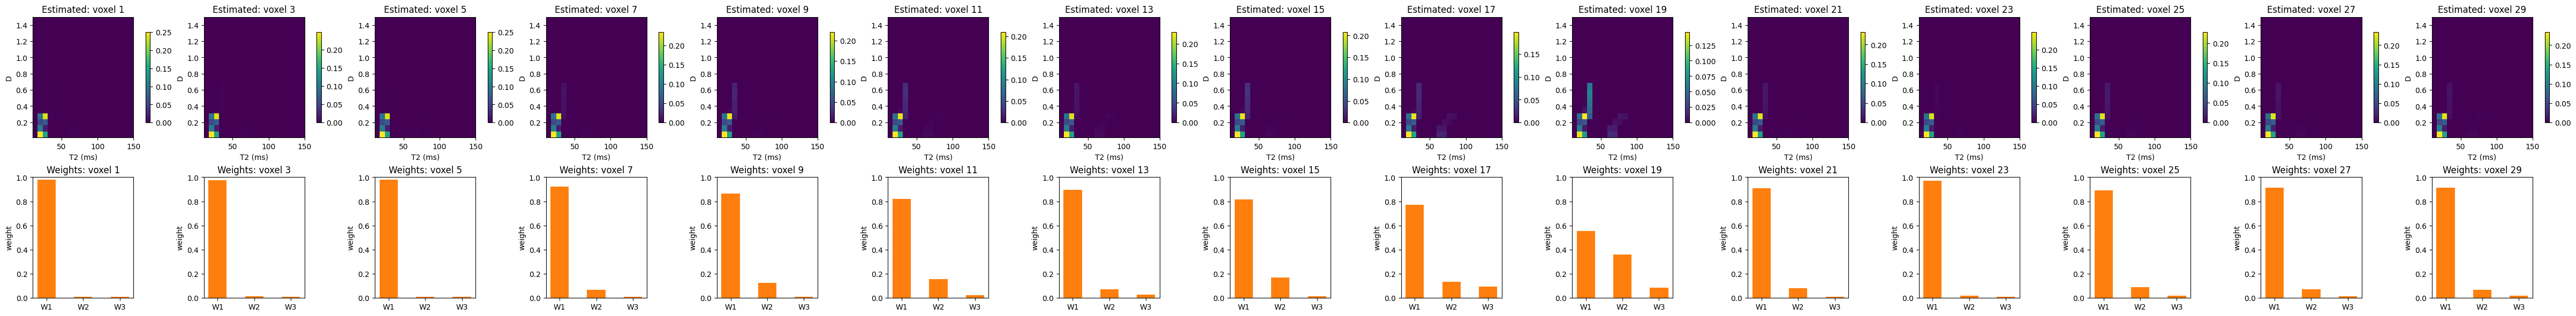

In [ ]:
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 1.5, 150.0, 20, 20  
#Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 0.75, 100.0, 20, 20  
voxels_to_show = [1,3,5,7,9,11,13,15,17,19, 21,23,25,27,29]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y = np.load(f"{OUT}/Y_slice42.npy")             # (nTE*nB, V)
acq = np.load(f"{OUT}/acq_table_slice42.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")

# subtract the signal floor: mean background (well outside the brain) for each (b, TE) row
from scipy.ndimage import binary_dilation
brain_slice = nib.load(os.path.join(DATA_DIR, "bet4animal_brainmask_f08_mask.nii.gz")).get_fdata()[:, :, SLICE_IDX] > 0
bg_slice = ~binary_dilation(brain_slice, iterations=10)
bg_slice[:5] = bg_slice[-5:] = False
bg_slice[:, :5] = bg_slice[:, -5:] = False
floor_sq = np.zeros(len(acq))
for run_idx, te in TE_BY_RUN.items():
    rows_this_run = np.where(acq[:, 1] == te)[0]
    if len(rows_this_run) == 0:
        continue
    bg = load_slice(run_idx)[bg_slice]
    bvals = load_bvals(run_idx)
    for row in rows_this_run:
        floor_sq[row] = (bg[:, np.abs(bvals - acq[row, 0]) <= BVAL_TOL] ** 2).mean()
Y = np.sqrt(np.maximum(Y ** 2 - floor_sq[:, None], 0))   # Rician (quadrature) correction


# cx, cy = 61, 66   # ROI centre (x, y) in voxels, read off the map
# near = np.argsort(np.hypot(voxel_xy[:, 0] - cx, voxel_xy[:, 1] - cy))[:30]

near = np.arange(0, Y.shape[1], Y.shape[1] // 30)[:30]   # 30 voxels spread evenly across the WM mask

Y, voxel_xy = Y[:, near], voxel_xy[near] 

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list)
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")
print("Y shape ", Y.shape, "\n")

Y = Y / np.median(Y[0]) * 30   # scale so M0 ≈ 300, like the simulations

# Define fitting parameters
K=3; # Number of compartments
V=Y.shape[1]; # Number of voxels
R=10   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
Y, A = Y[order], A[order]
b_list, TE_list = b_list[order], TE_list[order]
U, s, Vmat = apply_SVD_to_A(A, R)

plt.figure(figsize=(6, 6))
plt.imshow(b0_slice.T, cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="selected voxels")
plt.title(f"Slice {SLICE_IDX}: WM mask (orange), selected voxels (cyan)")
plt.legend(loc="upper right"); plt.axis("off"); plt.show()


rng=np.random.default_rng(0)
# Dirichlet vs entropy prior on the same data constrained C (non-negative, simplex on the D–T2 grid)
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

Y_dirichlet = Y

# Set intial conditions
C0_dirichlet, F_tissue = define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y_dirichlet - (U @ Csmall0_dirichlet @ W0_dirichlet) * M0_init_dirichlet) ** 2)


show_canonical_spectra([('initial_C', C0_dirichlet)])
print("\n")



for name, kwargs in priors.items():
    # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
    W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
        Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=400,
        sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=True,
        m0_prior=M0_init_dirichlet, m0_prior_sigma=3, alpha_update_start=5,
        c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
        verbose_every=100, **kwargs)
    print(f"{name} prior: estimated C")
    show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
    F_est = C_est_dirichlet @ W_est_dirichlet
    show_voxelwise_spectra_est(F_est, W_est_dirichlet, voxels_to_show)
